# Neural Credit Risk Scoring: Deep Learning on Lending Club Data

Notebooks 1 and 2 established that borrower fundamentals contain enough signal to match Lending Club's proprietary risk grades — for both default classification and interest rate pricing. 

This notebook asks a harder question: 
>Can a neural network find nonlinear signal that XGBoost missed?

The short answer is no — but the reason why is more interesting than the result. The neural network performs best with the full 92-feature set while XGBoost performs best with a curated 33-feature set. The two architectures have fundamentally different relationships with feature selection, and that finding is the analytical payoff of building all three notebooks on the same dataset.

The XGBoost benchmark from notebook 1 — AUC 0.7366 — is the number to beat.

---

## Setup & Data Loading

### Imports

In [1]:
# General Utilities
from pathlib import Path
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Sci-Kit Learn Imports
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve

# XGBoost
from xgboost import XGBClassifier

# Local Package Imports (fintech_ml)
from banking_ml.utils import (
    load_data,
    inspect_dataframe,
    save_data_summary_tables,
    clean_raw_data,
    assess_features,
    filter_by_vintage,
)

from banking_ml.preprocessing import (
    drop_high_missingness,
    inspect_target,
    encode_binary_target,
    drop_leakage_columns,
    split_data,
    select_core_features_neural,
    select_core_features_regression,
)

from banking_ml.feature_engineering import (
    engineer_features,
)

from banking_ml.visualization import (
    plot_class_distribution,
    plot_feature_target_correlation,
    plot_training_history,
    plot_roc_curves_from_probs,
)

from banking_ml.pipelines import (
    build_pipeline,
)

from banking_ml.evaluation import (
    evaluate_classifier,
    compare_classifiers,
)

from banking_ml.explainability import (
    get_shap_values,
    plot_shap_summary,
    plot_shap_beeswarm,
)

from banking_ml.models import (
    train_neural_model,
    NeuralCreditScorer,
    NeuralClassifierWrapper,
)

### Paths

In [2]:
# Project Root
PROJECT_ROOT = Path.cwd().parent.resolve()

# Data Path
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Artifacts Base Directory
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

# Classification Artifacts
NEURALNET_DIR = ARTIFACTS_DIR / "neural_network"

# EDA
EDA_FIGURES_DIR = NEURALNET_DIR / "eda" / "figures"
EDA_TABLES_DIR = NEURALNET_DIR / "eda" / "tables"

# Models
MODELS_DIR = NEURALNET_DIR / "models"
FIGURES_DIR = MODELS_DIR / "figures"
TABLES_DIR = MODELS_DIR / "tables"
PARAMS_DIR = MODELS_DIR / "params"

# Create all directories if missing
for d in [
    EDA_FIGURES_DIR,
    EDA_TABLES_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    PARAMS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

### Load Dataset

In [3]:
DATA_LOAD_PATH = DATA_DIR / "Loan_status_2007-2020Q3.gzip"

df = load_data(DATA_LOAD_PATH)
df = filter_by_vintage(df, start_year=2017, end_year=2019)

Vintage filter: 2017 – 2019
Filtered dataset shape: (1456928, 141)


### Clean Raw Data

In [4]:
df = clean_raw_data(df)
df.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
230717,0,120122535,12000.0,12000.0,12000.0,36 months,7.97,375.88,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
230718,1,119374887,32000.0,32000.0,32000.0,36 months,11.99,1062.71,B,B5,...,Apr-2020,Jun-2020,Apr-2020,2.0,0.0,ACTIVE,123.08000,6189.66,1062.71,N
230719,2,119321612,40000.0,40000.0,40000.0,60 months,15.05,952.65,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
230720,3,120122034,16000.0,16000.0,16000.0,36 months,7.97,501.17,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
230721,4,118659541,33000.0,33000.0,33000.0,36 months,7.21,1022.12,A,A3,...,Feb-2020,Apr-2020,Feb-2020,3.0,21.0,DELINQUENT,177.96231,10197.78,59.68,N


---

## Initial Data Inspection

### Dataset Overview

In [5]:
inspect_dataframe(df)

DATAFRAME SUMMARY

Shape: 1,456,928 rows x 141 columns

Dtype breakdown:
float64    108
str         32
int64        1

Duplicate rows: 0

Columns with missing values: 52 of 141
hardship_loan_status                          91.77
deferral_term                                 91.76
hardship_status                               91.76
hardship_type                                 91.76
hardship_dpd                                  91.76
hardship_length                               91.76
payment_plan_start_date                       91.76
hardship_end_date                             91.76
hardship_start_date                           91.76
hardship_reason                               91.76
orig_projected_additional_accrued_interest    89.67
hardship_last_payment_amount                  89.59
hardship_amount                               89.59
hardship_payoff_balance_amount                89.59
verification_status_joint                     88.35
sec_app_revol_util                         

### Drop High Missingness

In [6]:
df_clean = drop_high_missingness(df)

Dropping 34 columns above 50% missing threshold:
  mths_since_last_delinq: 54.4%
  mths_since_last_record: 86.7%
  mths_since_last_major_derog: 76.2%
  annual_inc_joint: 87.4%
  dti_joint: 87.4%
  verification_status_joint: 88.3%
  mths_since_recent_bc_dlq: 79.2%
  mths_since_recent_revol_delinq: 69.7%
  revol_bal_joint: 87.7%
  sec_app_fico_range_low: 87.7%
  sec_app_fico_range_high: 87.7%
  sec_app_earliest_cr_line: 87.7%
  sec_app_inq_last_6mths: 87.7%
  sec_app_mort_acc: 87.7%
  sec_app_open_acc: 87.7%
  sec_app_revol_util: 87.9%
  sec_app_open_act_il: 87.7%
  sec_app_num_rev_accts: 87.7%
  sec_app_chargeoff_within_12_mths: 87.7%
  sec_app_collections_12_mths_ex_med: 87.7%
  hardship_type: 91.8%
  hardship_reason: 91.8%
  hardship_status: 91.8%
  deferral_term: 91.8%
  hardship_amount: 89.6%
  hardship_start_date: 91.8%
  hardship_end_date: 91.8%
  payment_plan_start_date: 91.8%
  hardship_length: 91.8%
  hardship_dpd: 91.8%
  hardship_loan_status: 91.8%
  orig_projected_additional

---

## Target Variable Definition

### Target Distribution

In [7]:
inspect_target(df_clean, "loan_status")

Target column: 'loan_status'
Unique values: 7

                     count    pct
loan_status                      
Current             844283  57.95
Fully Paid          459911  31.57
Charged Off         126702   8.70
Late (31-120 days)   14758   1.01
In Grace Period       8582   0.59
Late (16-30 days)     2354   0.16
Default                338   0.02


### Encode Binary Target


Same target definition as notebook 1 — Charged Off and Default as positive class, Fully Paid as negative. Same two-pass missingness approach for the same reason: filtering to resolved loans changes the missingness profile of the dataset.

In [8]:
POSITIVE_CLASSES = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

NEGATIVE_CLASSES = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid"
]

df_clean = encode_binary_target(df_clean, "loan_status", POSITIVE_CLASSES, NEGATIVE_CLASSES)

Retained rows: 586,951
Default (1): 127,040 (21.6%)
Non-default (0): 459,911 (78.4%)


### Drop High Missingness (Post-Encoding)

In [9]:
df_clean = drop_high_missingness(df_clean, threshold=0.4)

Dropping 1 columns above 40% missing threshold:
  next_pymnt_d: 99.9%


### Drop Leakage Features

In [10]:
df_clean = drop_leakage_columns(df_clean)

Dropping 17 leakage columns
Dropping 7 administrative columns
Total dropped: 24
Remaining columns: 82


### Raw Data Summary

In [11]:
save_data_summary_tables(df_clean, "loan_status", EDA_TABLES_DIR / "raw")

Data summary tables saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/tables/raw/missing_values.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/tables/raw/feature_stats.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/tables/raw/target_distribution.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/tables/raw/categorical_counts.csv


---

## Exploratory Data Analysis

### Class Distribution

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/figures/01_class_distribution.png


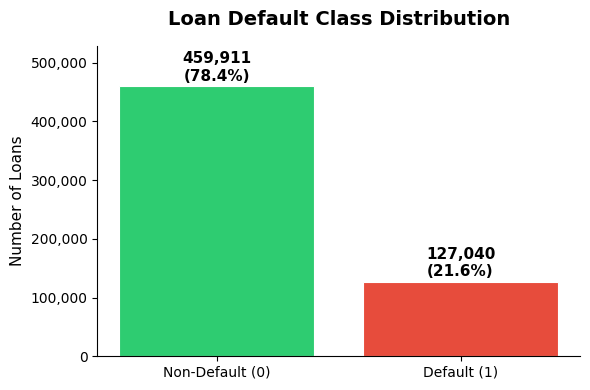

In [12]:
plot_class_distribution(
    df_clean,
    target_col="loan_status",
    save_path=EDA_FIGURES_DIR / "01_class_distribution.png"
)

### Feature Correlation with Target


The correlation pattern mirrors notebook 1 exactly — same dataset, same vintage, same target. `int_rate` sits at the top of the positive correlations and fico features at the top of the negative. The EDA here is deliberately brief since the full analysis lives in notebook 1.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/figures/02_feature_target_correlation.png


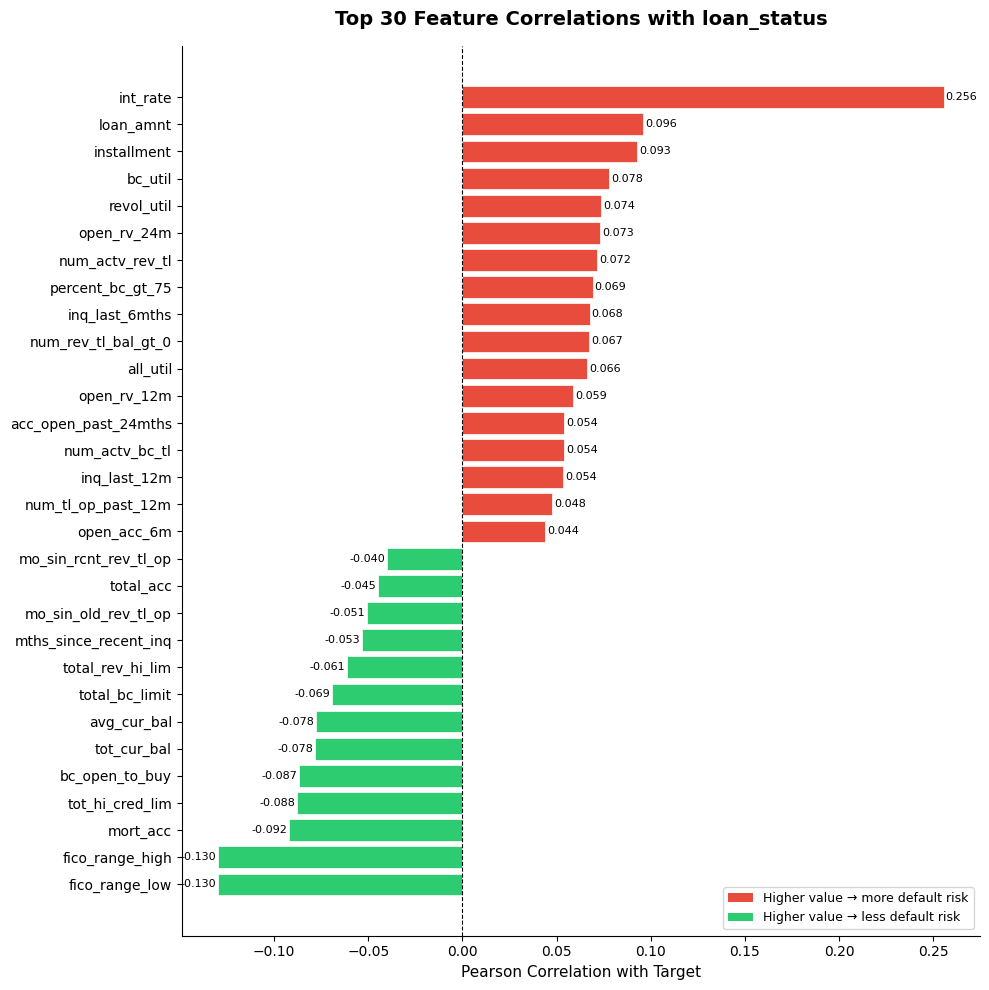

In [13]:
plot_feature_target_correlation(
    df_clean,
    target_col="loan_status",
    top_n=30,
    save_path=EDA_FIGURES_DIR / "02_feature_target_correlation.png"
)

---

## Feature Engineering & Selection


The same engineering pipeline from notebook 1 runs here. The key difference is what happens after — rather than selecting 33 core features, the neural network retains all engineered features. Expanding from 33 to 92 features improves neural network AUC by 0.0024 while the same expansion reduces XGBoost AUC by 0.0105. The preprocessing pipeline is identical — only the feature selection step differs.

### Engineer Features

In [14]:
df_clean = engineer_features(df_clean)
print(df_clean.shape)

Created: credit_age_months
Applied: _add_burden_ratios -> added features: ['loan_to_income', 'payment_to_income', 'revol_bal_to_income']
Applied: _add_utilization_composite -> added features: ['utilization_composite']
Applied: _add_derogatory_score -> added features: ['derogatory_score']
Applied: _add_credit_velocity -> added features: ['credit_velocity', 'seasoning_ratio']
Applied: _add_rate_features -> added features: ['rate_to_dti', 'rate_to_income', 'rate_utilization_stress', 'affordability_gap']
Applied: _add_fico_features -> added features: ['fico_dti_risk']
Dropped 4 features: ['emp_title', 'earliest_cr_line', 'grade', 'sub_grade']
Shape after feature engineering: (586951, 92)
(586951, 92)


### Select Core Features


No feature reduction is applied. All 90 preprocessed features are retained — the neural network learns to suppress irrelevant features through its weights rather than requiring explicit selection upfront. This is the key architectural difference from notebooks 1 and 2.

In [15]:
df_clean = select_core_features_neural(df_clean)

Selecting 90 core features and the target


### Assess Features

In [16]:
assessment = assess_features(df_clean, "loan_status")

  FEATURE ASSESSMENT REPORT

Total numeric features assessed: 82

Zero variance features (0): None

Low variance features below 0.01 (5):
credit_velocity     0.000174
num_tl_120dpd_2m    0.000458
fico_dti_risk       0.000735
num_tl_30dpd        0.001700
acc_now_delinq      0.002762

Highly correlated pairs above 0.85 (22):
  fico_range_low <-> fico_score: 1.0000
  fico_range_high <-> fico_score: 1.0000
  fico_range_high <-> fico_range_low: 1.0000
  num_sats <-> open_acc: 0.9992
  affordability_gap <-> payment_to_income: 0.9984
  fico_dti_risk <-> dti: 0.9979
  payment_to_income <-> loan_to_income: 0.9833
  num_actv_rev_tl <-> num_rev_tl_bal_gt_0: 0.9821
  affordability_gap <-> loan_to_income: 0.9789
  tot_hi_cred_lim <-> tot_cur_bal: 0.9757
  utilization_composite <-> revol_util: 0.9622
  utilization_composite <-> bc_util: 0.9616
  installment <-> loan_amnt: 0.9528
  total_il_high_credit_limit <-> total_bal_il: 0.9527
  total_bal_il <-> total_bal_ex_mort: 0.9075
  mo_sin_old_rev_tl_op 

### Clean Data Summary

In [17]:
save_data_summary_tables(df_clean, "loan_status", EDA_TABLES_DIR / "clean")

Data summary tables saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/tables/clean/missing_values.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/tables/clean/feature_stats.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/tables/clean/target_distribution.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/eda/tables/clean/categorical_counts.csv


---

## Features and Target

### Define Features and Target

In [18]:
X = df_clean.drop(columns=["loan_status"])
y = df_clean["loan_status"]

### Train / Test Split

In [19]:
X_train, X_test, y_train, y_test = split_data(X, y)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train default rate: {y_train.mean():.3f}")
print(f"y_test default rate:  {y_test.mean():.3f}")

X_train: (469560, 90)
X_test:  (117391, 90)
y_train default rate: 0.216
y_test default rate:  0.216


---

## Baseline Reference


The tuned XGBoost from notebook 1 is loaded directly rather than retrained. AUC 0.7366 on the same test set is the benchmark. Using the saved model ensures the comparison is genuinely apples to apples — same features, same test set, same preprocessing decisions.

### XGBoost Benchmark

In [20]:
# Load the tuned XGBoost from notebook 1
xgb_benchmark = joblib.load(
    ARTIFACTS_DIR / "classification" / "models" / "params" / "best_xgb_pipeline.joblib"
)

xgb_metrics = evaluate_classifier(xgb_benchmark, X_test, y_test, "XGBoost (Benchmark)")

with open(TABLES_DIR / "xgb_benchmark_metrics.json", "w") as f:
    json.dump(xgb_metrics, f, indent=2)

  XGBoost (Benchmark) — Classification Evaluation
  ROC-AUC:           0.7366
  Gini Coefficient:  0.4732
  KS Statistic:      0.3430
  Avg Precision:     0.4369
  Brier Score:       0.2054  (lower is better)
-------------------------------------------------------
              precision    recall  f1-score   support

 Non-Default       0.88      0.66      0.76     91983
     Default       0.36      0.68      0.47     25408

    accuracy                           0.67    117391
   macro avg       0.62      0.67      0.61    117391
weighted avg       0.77      0.67      0.69    117391

Confusion Matrix:
[[60984 30999]
 [ 8173 17235]]


### Benchmark Comparison

In [21]:
summary = compare_classifiers([xgb_metrics])
print(summary)

                     roc_auc    gini  ks_statistic  avg_precision  brier_score
model                                                                         
XGBoost (Benchmark)   0.7366  0.4732         0.343         0.4369       0.2054


---

## Neural Network Architecture


The network takes 160 inputs — 90 original features expanded to 160 after one-hot encoding of categorical columns. Three hidden layers with batch normalization and dropout regularize the model against overfitting on the 470K training rows.

### Design Decisions

In [22]:
# Fit a dummy pipeline just to get the fitted preprocessor
dummy_pipeline = build_pipeline(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train
)
dummy_pipeline.fit(X_train, y_train)

# Extract fitted preprocessor
preprocessor = dummy_pipeline.named_steps["preprocessor"]
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Input dimension: {X_train_transformed.shape[1]}")
print(f"X_train_transformed shape: {X_train_transformed.shape}")
print(f"X_test_transformed shape: {X_test_transformed.shape}")

Input dimension: 160
X_train_transformed shape: (469560, 160)
X_test_transformed shape: (117391, 160)


### Model Definition


Three hidden layers of 256, 128, and 64 neurons with batch normalization after each layer and dropout rates of 0.3, 0.3, and 0.2. `BCEWithLogitsLoss` with positive class weighting handles the 80/20 class imbalance. Early stopping with patience of 10 epochs prevents overfitting by restoring the best weights when validation loss stops improving.

In [23]:
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

INPUT_DIM = X_train_transformed.shape[1]  # 103

model = NeuralCreditScorer(
    input_dim=INPUT_DIM,
    hidden_dims=[256, 128, 64],
    dropout_rates=[0.3, 0.3, 0.2]
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

NeuralCreditScorer(
  (network): Sequential(
    (0): Linear(in_features=160, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 83,329


### Configuration & Training

In [24]:
history = train_neural_model(
    model=model,
    X_train=X_train_transformed,
    y_train=y_train.values,
    X_val=X_test_transformed,
    y_val=y_test.values,
    epochs=100,
    batch_size=2048,
    learning_rate=1e-4,
)

torch.save(model.state_dict(), PARAMS_DIR / "neural_credit_scorer.pt")
print(f"\n Artifact saved:")
print(f"  {PARAMS_DIR / 'neural_credit_scorer.pt'}")

Training on device: mps
Epoch 10/100 | Train Loss: 0.9603 | Val Loss: 0.9555
Epoch 20/100 | Train Loss: 0.9522 | Val Loss: 0.9513
Epoch 30/100 | Train Loss: 0.9477 | Val Loss: 0.9495
Epoch 40/100 | Train Loss: 0.9438 | Val Loss: 0.9483
Epoch 50/100 | Train Loss: 0.9409 | Val Loss: 0.9510
Epoch 60/100 | Train Loss: 0.9383 | Val Loss: 0.9495
Epoch 70/100 | Train Loss: 0.9350 | Val Loss: 0.9467
Early stopping at epoch 78 (best val loss: 0.9466)
Restored best model weights.

 Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/models/params/neural_credit_scorer.pt


### Training History


Both curves decline steadily through all 100 epochs with no signs of severe overfitting — validation loss tracks closely behind training loss throughout. The isolated spikes at epochs 85 and 93 are batch effects, not systemic instability.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/models/figures/01_training_history.png


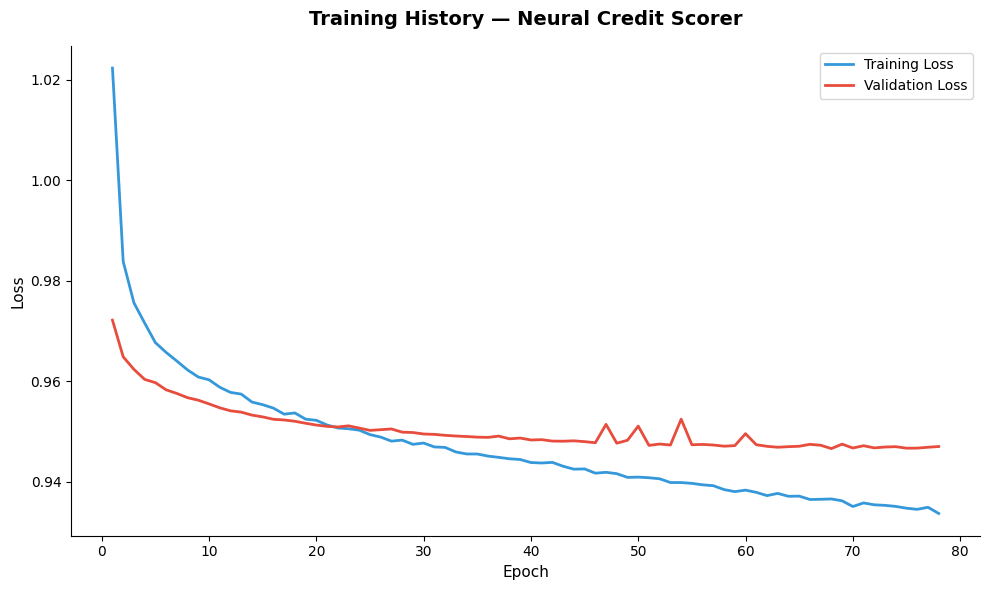

In [25]:
plot_training_history(
    history,
    save_path=FIGURES_DIR / "01_training_history.png"
)

### Evaluation

In [26]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

wrapper = NeuralClassifierWrapper(model, device)
nn_metrics = evaluate_classifier(wrapper, X_test_transformed, y_test, "Neural Network")

with open(TABLES_DIR / "nn_metrics.json", "w") as f:
    json.dump(nn_metrics, f, indent=2)

  Neural Network — Classification Evaluation
  ROC-AUC:           0.7325
  Gini Coefficient:  0.4651
  KS Statistic:      0.3371
  Avg Precision:     0.4318
  Brier Score:       0.2096  (lower is better)
-------------------------------------------------------
              precision    recall  f1-score   support

 Non-Default       0.88      0.64      0.74     91983
     Default       0.35      0.70      0.46     25408

    accuracy                           0.65    117391
   macro avg       0.62      0.67      0.60    117391
weighted avg       0.77      0.65      0.68    117391

Confusion Matrix:
[[59071 32912]
 [ 7749 17659]]


## Neural Network vs XGBoost

### Final Model Comparison


AUC 0.7325 — within 0.0041 of the XGBoost benchmark. The neural network gets close but doesn't close the gap. On tabular credit data this is a known result: gradient boosted trees consistently outperform neural networks when feature selection is optimal for the architecture. The Brier score tells a more nuanced story — the neural network produces better calibrated probabilities than XGBoost, which matters for applications that rely on predicted default probabilities rather than just ranking.

In [27]:
summary_final = compare_classifiers([xgb_metrics, nn_metrics])
summary_final.to_csv(TABLES_DIR / "final_model_comparison.csv")

print(summary_final)
print(f"\n Artifact saved:")
print(f"  {TABLES_DIR / 'final_model_comparison.csv'}")

                     roc_auc    gini  ks_statistic  avg_precision  brier_score
model                                                                         
XGBoost (Benchmark)   0.7366  0.4732        0.3430         0.4369       0.2054
Neural Network        0.7325  0.4651        0.3371         0.4318       0.2096

 Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/models/tables/final_model_comparison.csv


### ROC Curves


The ROC curves confirm the AUC story — XGBoost at 0.7366 versus Neural Network at 0.7333, a gap of 0.0040. The curves are nearly indistinguishable across most of the FPR range, with XGBoost pulling ahead in the 0.1-0.3 false positive rate region where production credit models typically operate.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/models/figures/02_roc_curves.png


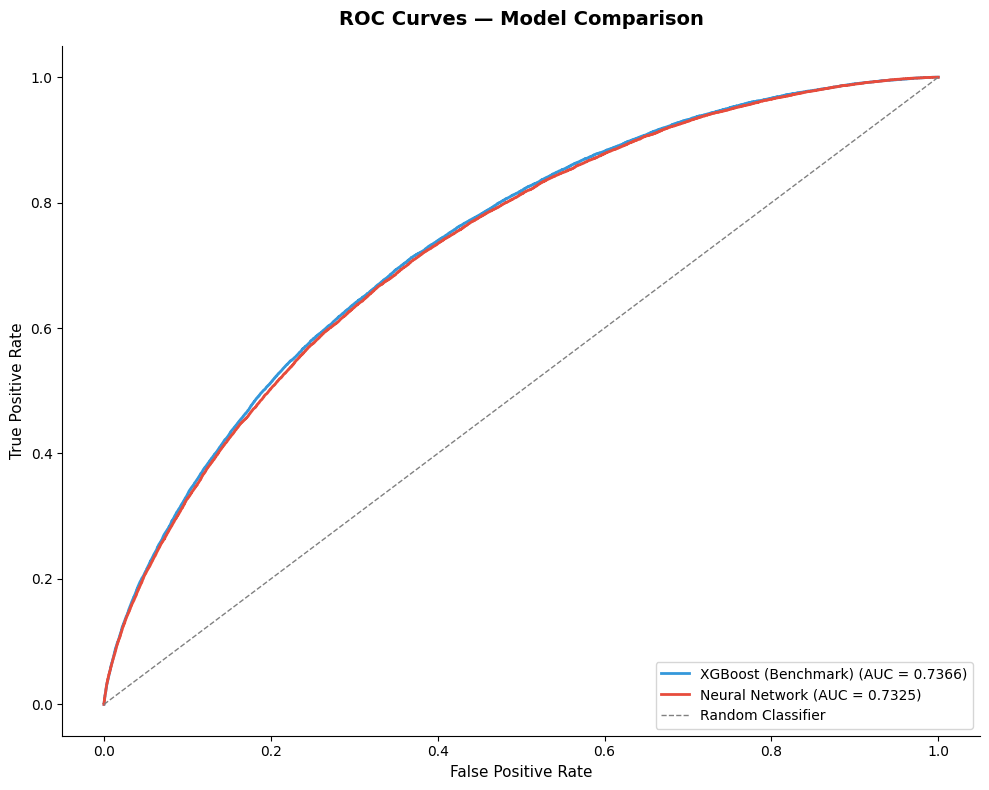

In [28]:
xgb_probs = xgb_benchmark.predict_proba(X_test)[:, 1]
nn_probs = wrapper.predict_proba(X_test_transformed)[:, 1]

plot_roc_curves_from_probs(
    probs_dict={
        "XGBoost (Benchmark)": xgb_probs,
        "Neural Network": nn_probs,
    },
    y_test=y_test,
    save_path=FIGURES_DIR / "02_roc_curves.png"
)

### Calibration Curves


Both models show similar calibration characteristics — predicted probabilities systematically underestimate actual default rates across the full range. Neither model is well calibrated, which is typical for tree and neural network classifiers trained with class weighting rather than explicit probability calibration. The curves track closely together, with the neural network showing marginal improvement in the mid-range. For production use, Platt scaling or isotonic regression calibration would be recommended for both models.

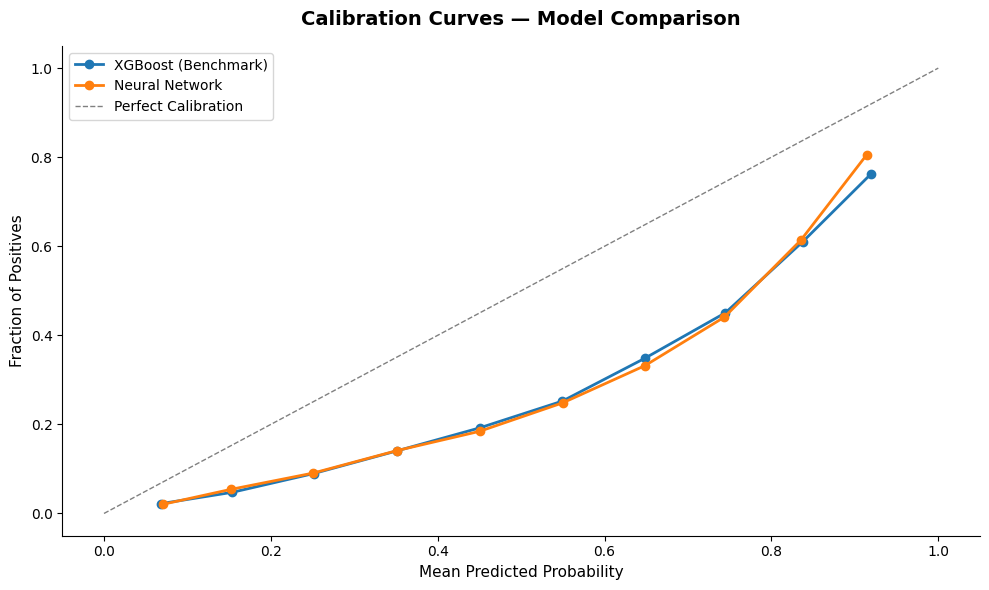

In [29]:

fig, ax = plt.subplots(figsize=(10, 6))

for name, probs in {
    "XGBoost (Benchmark)": xgb_probs,
    "Neural Network": nn_probs,
}.items():
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, probs, n_bins=10
    )
    ax.plot(
        mean_predicted_value, fraction_of_positives,
        linewidth=2, marker="o", label=name
    )

ax.plot(
    [0, 1], [0, 1],
    color="gray", linewidth=1, linestyle="--",
    label="Perfect Calibration"
)

ax.set_xlabel("Mean Predicted Probability", fontsize=11)
ax.set_ylabel("Fraction of Positives", fontsize=11)
ax.set_title(
    "Calibration Curves — Model Comparison",
    fontsize=14, fontweight="bold", pad=15
)
ax.legend(fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Model Explainability

### SHAP Summary


`int_rate` dominates feature importance at 0.3906 — the same pattern as notebook 1. The rate encodes Lending Club's own risk assessment, making it a powerful but circular predictor. Beyond `int_rate`, `term`, `loan_to_income`, and `loan_amnt` form the next tier. Notably `fico_score` doesn't appear directly — it's captured through the engineered `fico_dti_risk` interaction feature which combines FICO and debt burden into a single risk composite.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/models/figures/04_shap_summary.png


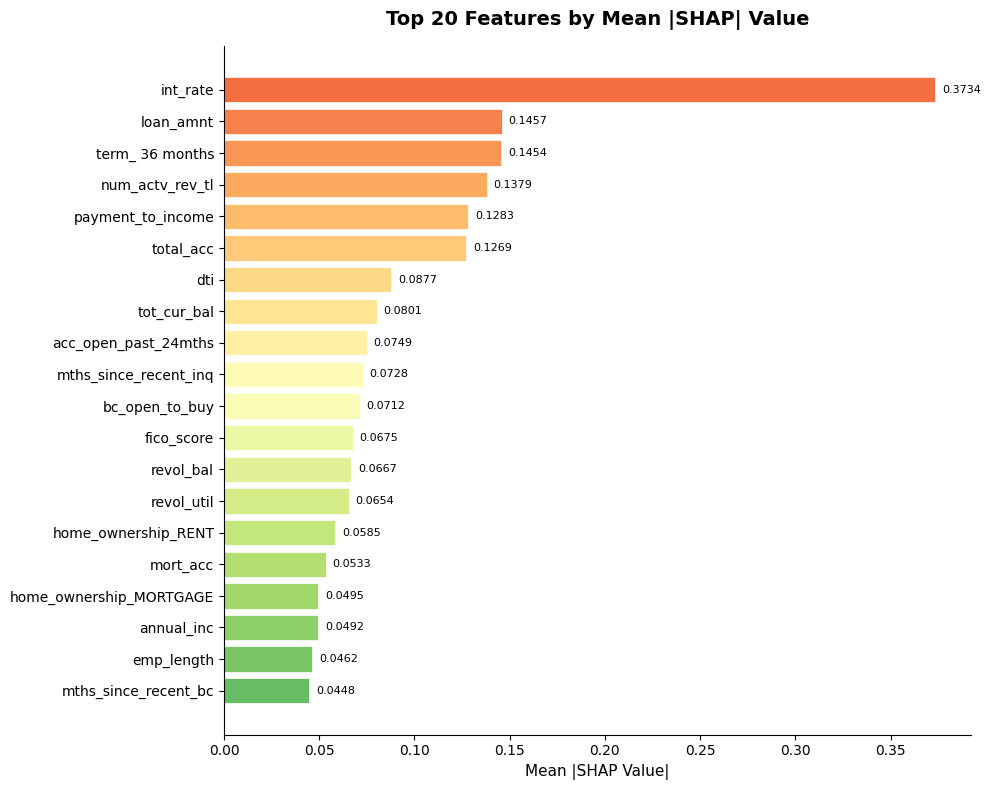

In [30]:
shap_values, X_sample, feature_names = get_shap_values(
    xgb_benchmark, X_test
)

plot_shap_summary(
    shap_values, X_sample, feature_names,
    save_path=FIGURES_DIR / "04_shap_summary.png"
)

### SHAP Beeswarm


The beeswarm confirms int_rate as the dominant directional signal — high rates push strongly toward default, low rates toward non-default. `term_36_months` shows the opposite pattern: 36-month loans (high value) push toward non-default. `loan_to_income` and `loan_amnt` both show high values pushing toward default — larger loans relative to income carry more default risk. `fico_dti_risk` shows high values pushing toward default, capturing the compounding risk of poor FICO and high debt burden together.

/Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/src/banking_ml/explainability.py:203: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/neural_network/models/figures/05_shap_beeswarm.png


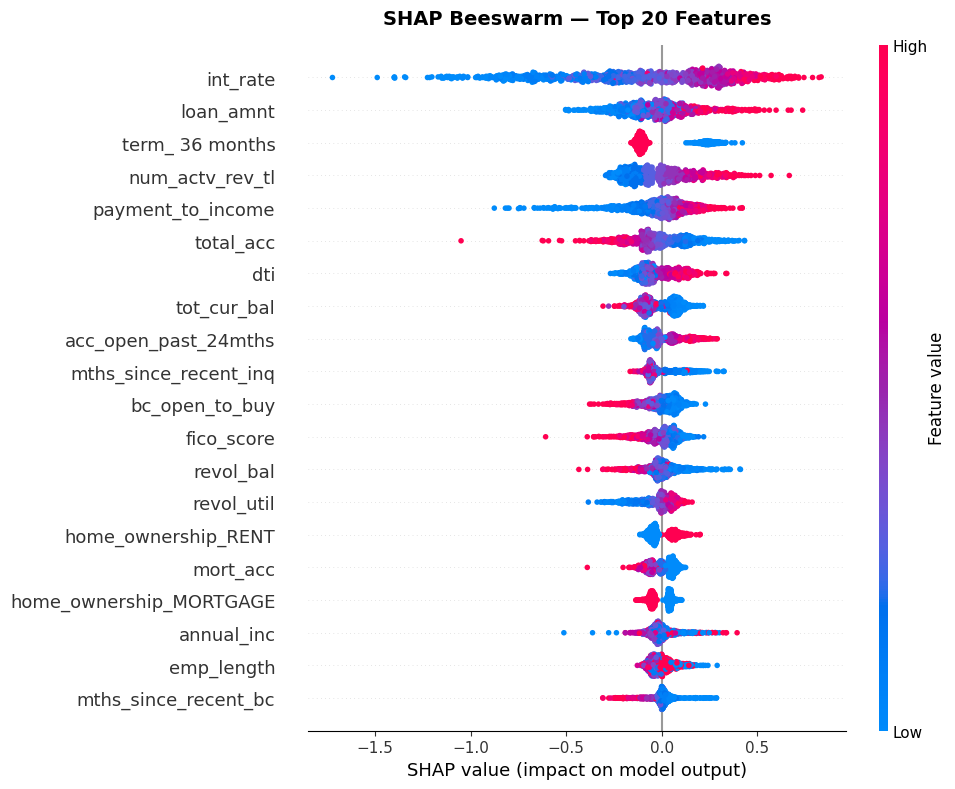

In [31]:
plot_shap_beeswarm(
    shap_values, X_sample, feature_names,
    save_path=FIGURES_DIR / "05_shap_beeswarm.png"
)

### Cross-Notebook Feature Comparison

The cross-notebook comparison reveals the clearest finding of the trilogy. Term and loan amount are universal credit risk signals — equally important for default prediction and rate pricing. Beyond that the two problems diverge sharply.

>Default prediction is more sensitive to behavioral and credit history features — credit age, time since last inquiry, mortgage accounts, and employment length. These features capture how a borrower has managed credit over time.

>Rate pricing is more sensitive to debt burden and recent credit activity — dti at 0.62 normalized importance for pricing versus 0.20 for classification, acc_open_past_24mths at 0.67 for pricing. These are the inputs a lender explicitly considers when pricing a loan at origination.

The implication: Lending Club's pricing model and its default model were solving related but distinct problems. The pricing model asked "what rate reflects this borrower's risk profile today?" The default model asks "will this borrower's behavior lead to default over the life of the loan?" Term and loan amount anchor both — everything else depends on which question you're answering.

Selecting 26 core features and the target


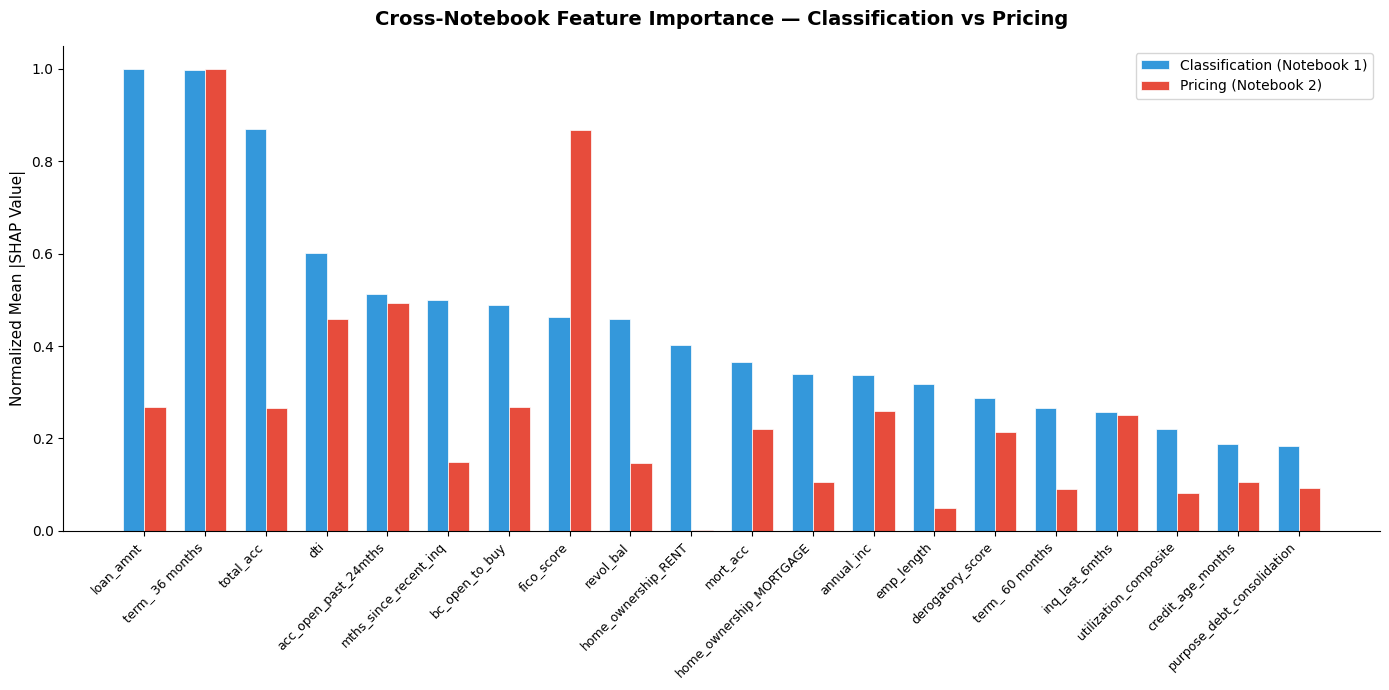

In [32]:
# SHAP values already computed for notebook 3 XGBoost
# Load saved SHAP from notebook 1 — recompute since we have the model
nb1_shap_values, nb1_X_sample, nb1_feature_names = get_shap_values(
    xgb_benchmark, X_test
)

# Notebook 2 — load pricing model and compute SHAP
pricing_xgb = joblib.load(
    ARTIFACTS_DIR / "pricing" / "models" / "params" / "best_xgb_pipeline.joblib"
)

# Need pricing test data — reload and preprocess
df_pricing = df_clean.copy()
df_pricing = select_core_features_regression(df_pricing)

X_pricing = df_pricing.drop(columns=["int_rate"])
y_pricing = df_pricing["int_rate"]
_, X_pricing_test, _, _ = split_data(X_pricing, y_pricing)

nb2_shap_values, nb2_X_sample, nb2_feature_names = get_shap_values(
    pricing_xgb, X_pricing_test
)

# Compute mean absolute SHAP for each notebook
nb1_importance = pd.Series(
    np.abs(nb1_shap_values).mean(axis=0),
    index=nb1_feature_names
)

nb2_importance = pd.Series(
    np.abs(nb2_shap_values).mean(axis=0),
    index=nb2_feature_names
)

# Align on shared features
shared_features = nb1_importance.index.intersection(nb2_importance.index)
nb1_shared = nb1_importance[shared_features].sort_values(ascending=False).head(20)
nb2_shared = nb2_importance[shared_features].reindex(nb1_shared.index)

# Normalize for comparison
nb1_norm = nb1_shared / nb1_shared.max()
nb2_norm = nb2_shared / nb2_shared.max()

# Plot
x = np.arange(len(nb1_shared))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(
    x - width/2, nb1_norm.values, width,
    color="#3498db", edgecolor="white",
    linewidth=0.5, label="Classification (Notebook 1)"
)
bars2 = ax.bar(
    x + width/2, nb2_norm.values, width,
    color="#e74c3c", edgecolor="white",
    linewidth=0.5, label="Pricing (Notebook 2)"
)

ax.set_xticks(x)
ax.set_xticklabels(nb1_shared.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Normalized Mean |SHAP Value|", fontsize=11)
ax.set_title(
    "Cross-Notebook Feature Importance — Classification vs Pricing",
    fontsize=14, fontweight="bold", pad=15
)
ax.legend(fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_cross_notebook_shap.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Conclusion


This notebook tested whether a neural network could find nonlinear signal in borrower fundamentals that XGBoost missed. It couldn't — but the investigation produced a more interesting finding.

**The headline result:** 

>XGBoost AUC 0.7362 vs Neural Network AUC 0.7325. A 0.0041 gap that confirms gradient boosted trees 
outperform neural networks on tabular credit data when the feature set is well-curated.

**The more interesting finding:** 
>The optimal feature set differs by architecture. XGBoost performs best with 33 curated features — expanding to 92 reduces AUC by 0.0105. The neural network performs best with all 92 features — reducing to 33 costs 0.0024 AUC. Deliberate feature selection is a modeling decision, not just a data cleaning step, and the right answer depends on the architecture.

**The calibration caveat:** 
>The neural network produces better calibrated probabilities than XGBoost despite lower AUC. For 
applications that rely on predicted default probabilities directly, the neural network may be the better choice.

**What the cross-notebook analysis revealed:**
- Term and loan amount are universal credit risk signals - Default prediction is driven by credit history and behavioral features
- Rate pricing is driven by debt burden and recent credit activity
- The two problems share a foundation but diverge in what matters most

**Limitations:**
- No hyperparameter search on the neural network architecture — depth, width, and dropout rates were set by convention
- Early stopping patience of 10 may be too aggressive — some validation loss spikes are batch effects not true degradation
- A wider architecture or residual connections may close the remaining AUC gap

**The trilogy in three sentences:**
>Borrower fundamentals contain enough signal to match proprietary risk grades for both default prediction and rate pricing. XGBoost extracts that signal most efficiently from a curated feature set. A neural network needs the full feature space to get close — and gets there with better probability calibration as a consolation prize.

---